In [ ]:
# Name : Hari Krishna Rachuri
# ID   : 2025DA04007
# Assignment 2 - Credit Card Default Prediction Using Machine Learning
# Source data - https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

*Step 2: Load Dataset*

In [3]:
# ==========================================================
# Step 1 : Load Dataset
# ==========================================================

df = pd.read_csv("UCI_Credit_Card.csv")

print("Dataset Shape :", df.shape)

Dataset Shape : (30000, 25)


In [5]:
# ==========================================================
# Dataset Exploration
# ==========================================================

print("\n==============================")
print("COLUMN NAMES")
print("==============================")
print(df.columns)

print("\n==============================")
print("DATA TYPES")
print("==============================")
print(df.dtypes)

print("\n==============================")
print("MISSING VALUES")
print("==============================")
print(df.isnull().sum())

print("\n==============================")
print("DUPLICATE RECORDS")
print("==============================")
print(df.duplicated().sum())

print("\n==============================")
print("SUMMARY STATISTICS")
print("==============================")
print(df.describe())


COLUMN NAMES
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

DATA TYPES
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5       

**Step 3: Data Preprocessing**

In [7]:
# ==========================================================
# Step 2 : Data Preprocessing
# ==========================================================

# Remove ID column
df.drop("ID", axis=1, inplace=True)

# Target Variable
target = "default.payment.next.month"

# ==========================================================
# Default Analysis
# ==========================================================

default_yes = df[df[target] == 1]
default_no = df[df[target] == 0]

print("\nTotal Customers =", len(df))
print("Default Customers =", len(default_yes))
print("Default Percentage =", round(len(default_yes)/len(df)*100,2), "%")

print("Non Default Customers =", len(default_no))
print("Non Default Percentage =", round(len(default_no)/len(df)*100,2), "%")




Total Customers = 30000
Default Customers = 6636
Default Percentage = 22.12 %
Non Default Customers = 23364
Non Default Percentage = 77.88 %


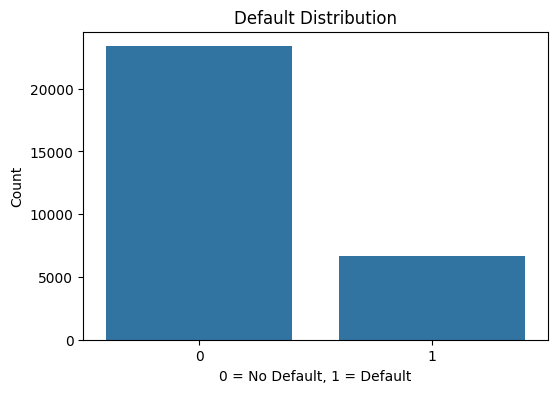

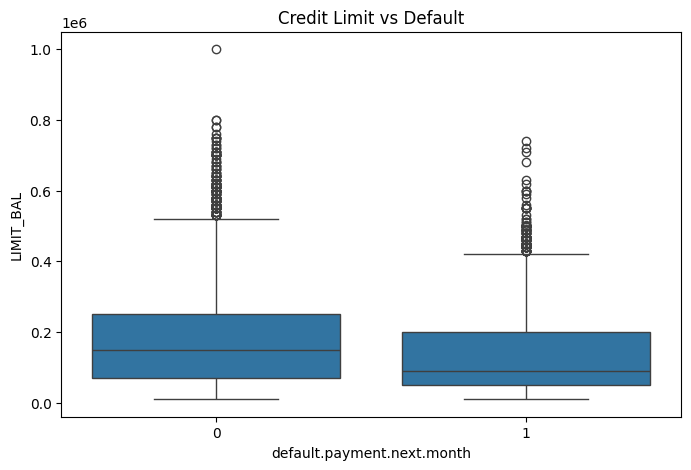

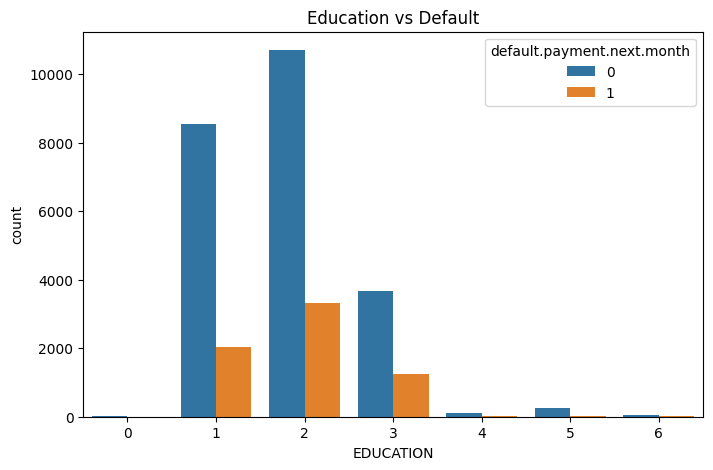

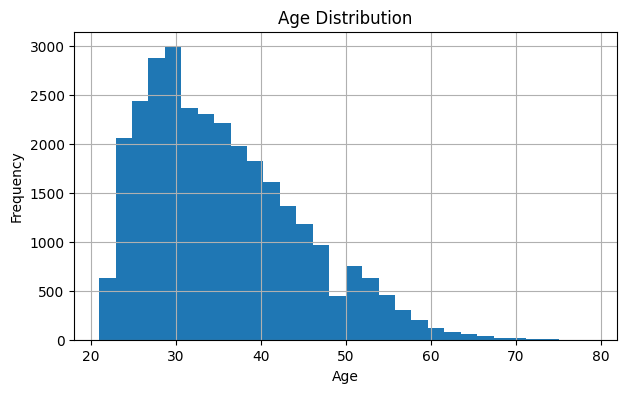

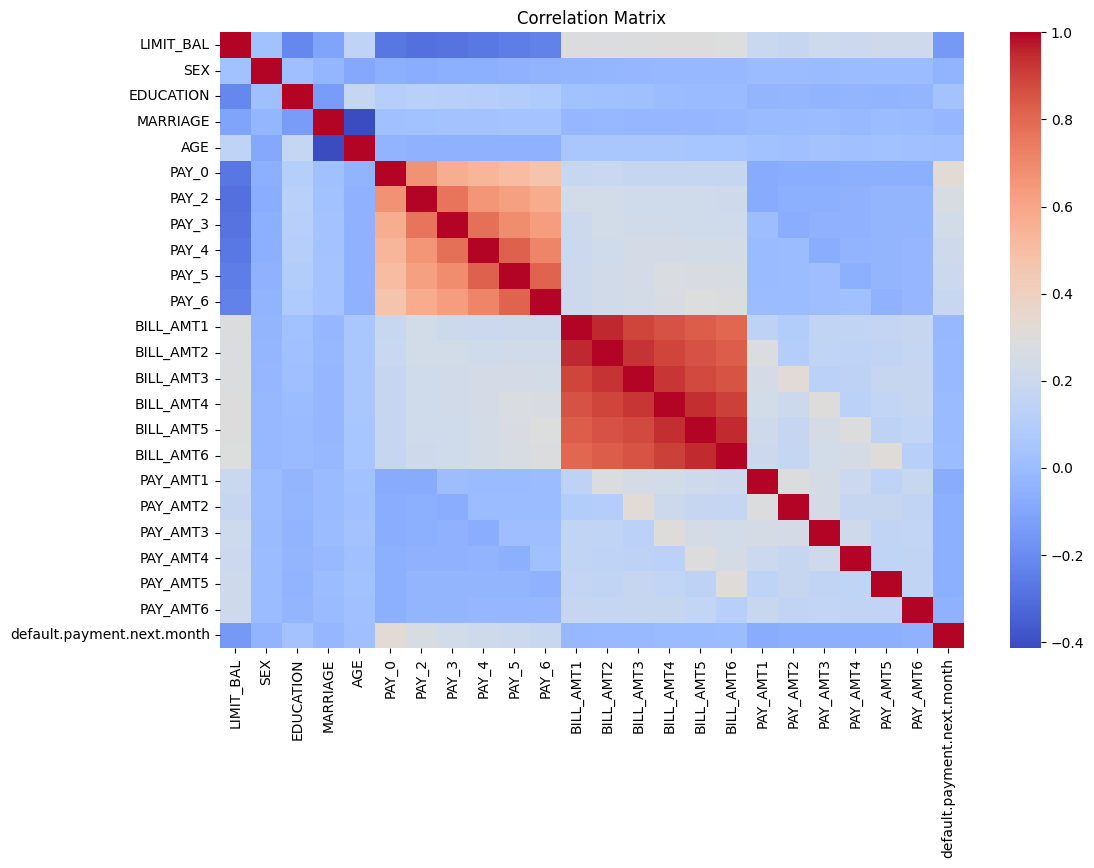

In [9]:
# ==========================================================
# Step 3 : Data Visualization
# ==========================================================

# Default Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Default Distribution")
plt.xlabel("0 = No Default, 1 = Default")
plt.ylabel("Count")
plt.show()

# Credit Limit vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x=target, y="LIMIT_BAL", data=df)
plt.title("Credit Limit vs Default")
plt.show()

# Education vs Default
plt.figure(figsize=(8,5))
sns.countplot(x="EDUCATION",
              hue=target,
              data=df)
plt.title("Education vs Default")
plt.show()

# Age Distribution
plt.figure(figsize=(7,4))
df["AGE"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



In [11]:
# ==========================================================
# Step 4 : Feature and Target Selection
# ==========================================================

X = df.drop(target, axis=1)
y = df[target]



In [19]:

# ==========================================================
# Step 5 : Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)




Training Shape : (24000, 23)
Testing Shape  : (6000, 23)


Churn Count and Percentage

**Step 4 - Data Visualization**

In [21]:
# ==========================================================
# Step 6 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# ==========================================================
# Step 7 : Evaluation Function
# ==========================================================

def evaluate_model(model,
                   X_train_data,
                   X_test_data,
                   y_train_data,
                   y_test_data):

    model.fit(X_train_data, y_train_data)

    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)

    precision = precision_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_data,
        y_pred
    )

    auc_score = roc_auc_score(
        y_test_data,
        model.predict_proba(X_test_data)[:,1]
    )

    return (
        accuracy,
        auc_score,
        precision,
        recall,
        f1,
        mcc
    )



In [25]:
# ==========================================================
# Logistic Regression
# ==========================================================

lr = LogisticRegression(max_iter=1000)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Logistic Regression Done")



Logistic Regression Done


In [27]:
# ==========================================================
# Decision Tree
# ==========================================================

dt = DecisionTreeClassifier(random_state=42)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Decision Tree Done")



Decision Tree Done


In [29]:
# ==========================================================
# KNN
# ==========================================================

knn = KNeighborsClassifier(n_neighbors=5)

knn_results = evaluate_model(
    knn,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("KNN Done")

KNN Done


In [36]:
# ==========================================================
# Naive Bayes
# ==========================================================

nb = GaussianNB()

nb_results = evaluate_model(
    nb,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Naive Bayes Done")



Naive Bayes Done


In [37]:
# ==========================================================
# Random Forest
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Random Forest Done")


Random Forest Done


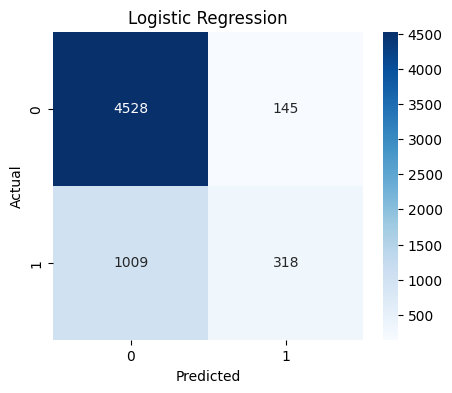

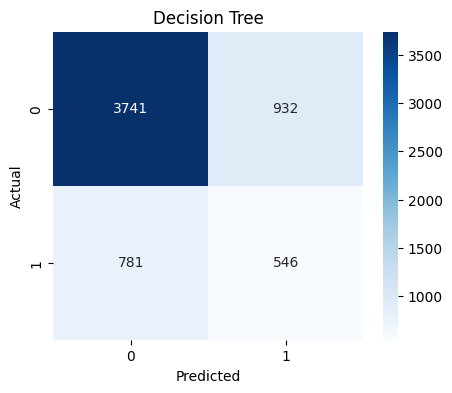

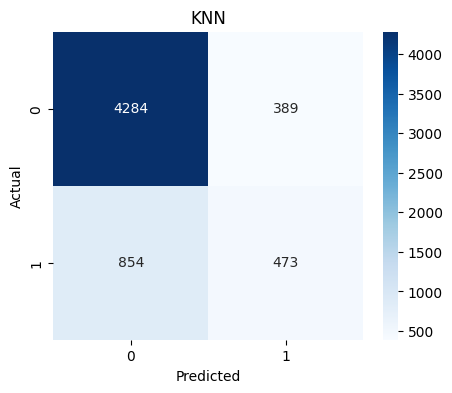

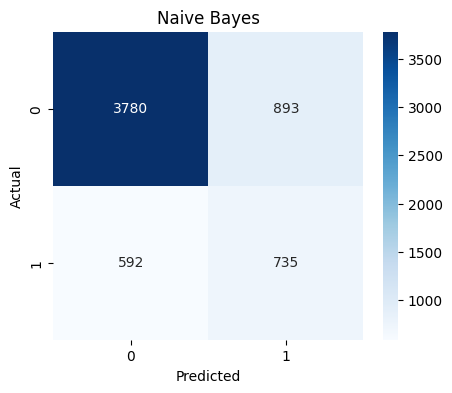

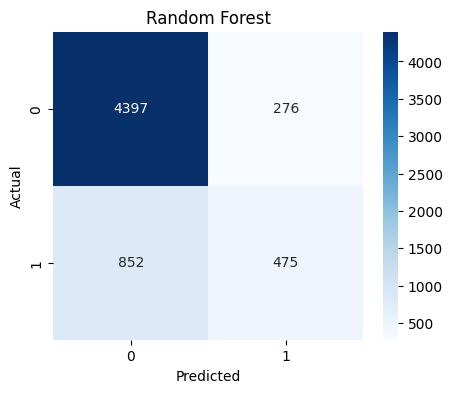

In [39]:
# ==========================================================
# Confusion Matrix
# ==========================================================

def plot_confusion_matrix(
        model,
        X_data,
        y_data,
        model_name):

    pred = model.predict(X_data)

    cm = confusion_matrix(
        y_data,
        pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(
    lr,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

plot_confusion_matrix(
    dt,
    X_test,
    y_test,
    "Decision Tree"
)

plot_confusion_matrix(
    knn,
    X_test_scaled,
    y_test,
    "KNN"
)

plot_confusion_matrix(
    nb,
    X_test_scaled,
    y_test,
    "Naive Bayes"
)

plot_confusion_matrix(
    rf,
    X_test,
    y_test,
    "Random Forest"
)



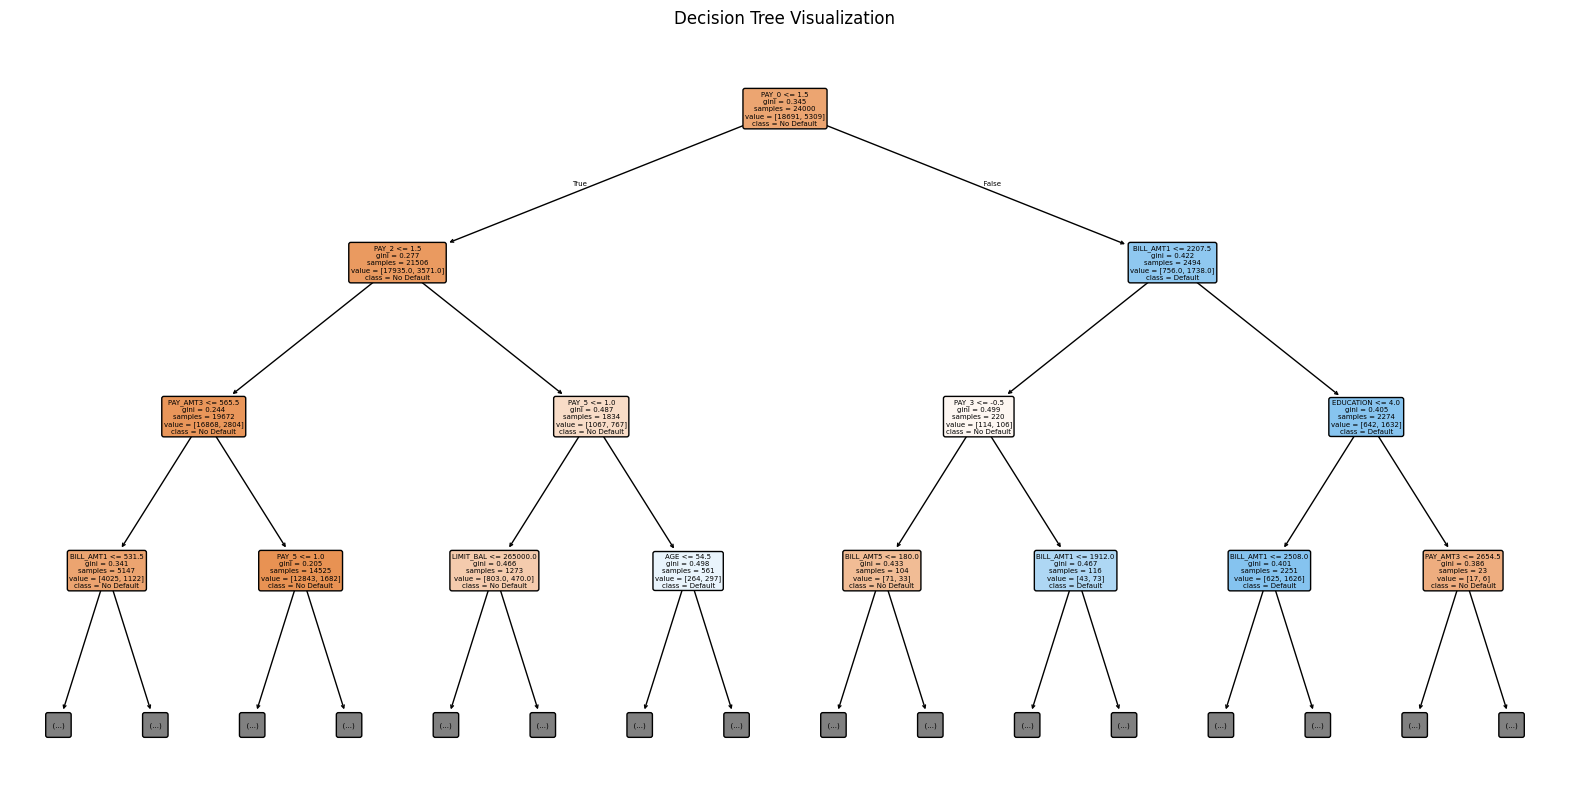

In [42]:
# ==========================================================
# Decision Tree Visualization
# ==========================================================

from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=[
        "No Default",
        "Default"
    ],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()



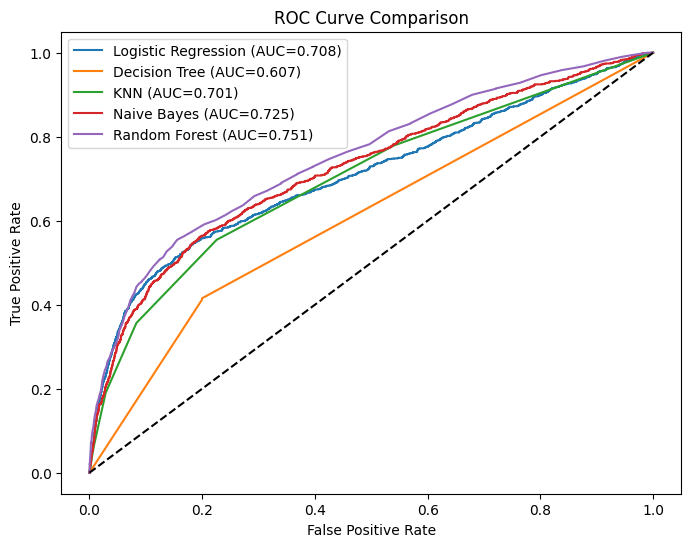

In [44]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "KNN": (knn, X_test_scaled),
    "Naive Bayes": (nb, X_test_scaled),
    "Random Forest": (rf, X_test)
}

for name, (model, X_data) in models.items():

    probs = model.predict_proba(X_data)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [46]:
# ==========================================================
# Save Models
# ==========================================================

import joblib
import os

os.makedirs(
    "model",
    exist_ok=True
)

joblib.dump(
    lr,
    "model/logistic_regression.pkl"
)

joblib.dump(
    dt,
    "model/decision_tree.pkl"
)

joblib.dump(
    knn,
    "model/knn.pkl"
)

joblib.dump(
    nb,
    "model/naive_bayes.pkl"
)

joblib.dump(
    rf,
    "model/random_forest.pkl"
)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("All models saved successfully")


All models saved successfully


In [48]:
# ==========================================================
# Model Comparison
# ==========================================================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Naive Bayes",
        "Random Forest"
    ],

    "Accuracy":[
        lr_results[0],
        dt_results[0],
        knn_results[0],
        nb_results[0],
        rf_results[0]
    ],

    "AUC Score":[
        lr_results[1],
        dt_results[1],
        knn_results[1],
        nb_results[1],
        rf_results[1]
    ],

    "Precision":[
        lr_results[2],
        dt_results[2],
        knn_results[2],
        nb_results[2],
        rf_results[2]
    ],

    "Recall":[
        lr_results[3],
        dt_results[3],
        knn_results[3],
        nb_results[3],
        rf_results[3]
    ],

    "F1 Score":[
        lr_results[4],
        dt_results[4],
        knn_results[4],
        nb_results[4],
        rf_results[4]
    ],

    "MCC Score":[
        lr_results[5],
        dt_results[5],
        knn_results[5],
        nb_results[5],
        rf_results[5]
    ]

})

print("\n")
print(results)





                 Model  Accuracy  AUC Score  Precision    Recall  F1 Score  \
0  Logistic Regression  0.807667   0.707636   0.686825  0.239638  0.355307   
1        Decision Tree  0.714500   0.607451   0.369418  0.411454  0.389305   
2                  KNN  0.792833   0.701435   0.548724  0.356443  0.432161   
3          Naive Bayes  0.752500   0.724930   0.451474  0.553881  0.497462   
4        Random Forest  0.812000   0.750596   0.632490  0.357950  0.457170   

   MCC Score  
0   0.324443  
1   0.204216  
2   0.323267  
3   0.338620  
4   0.374872  


In [50]:
# ==========================================================
# Best Model
# ==========================================================

best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("\nBest Model")
print(best_model)



Best Model
Model        Random Forest
Accuracy             0.812
AUC Score         0.750596
Precision          0.63249
Recall             0.35795
F1 Score           0.45717
MCC Score         0.374872
Name: 4, dtype: object
